# Autonomous Decision-Making Agent

In [ ]:
# Standard library imports
import os
import sys
import time
from datetime import datetime
from dataclasses import dataclass, field
from functools import wraps

# Ensure local modules are importable regardless of working directory
sys.path.insert(0, ".")

# Supporting modules (must exist alongside this notebook)
from color_logger import log_info, log_success, log_error, log_warn, log_section
from resilience import fail_gracefully
from mock_llm import MockLLM, MockVectorDB, MockResponse

log_success("All imports successful")

[SUCCESS 12:48:35] All imports successful


In [2]:
import os
os.environ["LLM_PROVIDER"] = "openai"

# ── Environment Detection & Simulation Mode Toggle ─────────────

# If an API key is found in .env or via getpass, live mode activates.
# Otherwise, Simulation Mode engages the MockLLM and MockVectorDB.

log_section("Environment Detection")

# Attempt to load .env (no-op if file missing)
try:
    from dotenv import load_dotenv
    load_dotenv()
    log_info("Loaded .env file")
except ImportError:
    log_warn("python-dotenv not installed — skipping .env loading")

# Check for API key
api_key = os.getenv("OPENAI_API_KEY", "").strip()

if not api_key:
    try:
        import getpass
        # In non-interactive environments, this will remain empty
        api_key = getpass.getpass(
            "Enter OpenAI API key (or press Enter for Simulation Mode): "
        ).strip()
    except (EOFError, OSError, Exception):
        api_key = ""

# ── Initialize clients based on mode ───────────────────────────
SIMULATION_MODE = not bool(api_key)

if SIMULATION_MODE:
    llm_client = MockLLM()
    vector_db = MockVectorDB()
    log_warn("SIMULATION MODE active — using MockLLM and MockVectorDB")
    log_info("No API key required. All agent demos will run with mock data.")
else:
    # ── Live LLM wrapper matching MockLLM.generate() interface ─
    try:
        from openai import OpenAI as _OpenAI

        class _LiveLLM:
            """Wraps OpenAI GPT-4o to match MockLLM.generate() interface.
            Returns MockResponse-compatible objects so downstream agent
            code works unchanged."""

            _INTENT_KW = {
                "service_outage": ["outage", "down", "not working", "internet", "offline"],
                "billing_issue": ["bill", "charge", "invoice", "payment", "refund"],
                "complex_technical": ["configure", "setup", "integrate", "deploy", "debug"],
                "marketing_campaign_plan": ["marketing", "campaign", "plan", "launch"],
                "healthcare_query": ["health", "medical", "patient", "diagnosis", "clinical"],
            }

            def __init__(self, client, model="gpt-4o"):
                self._client = client
                self._model = model
                self._fallback = MockLLM()

            def _detect_intent(self, prompt):
                lower = prompt.lower()
                for intent, kws in self._INTENT_KW.items():
                    if any(kw in lower for kw in kws):
                        return intent
                return "general_inquiry"

            def generate(self, prompt, **kwargs):
                try:
                    resp = self._client.chat.completions.create(
                        model=self._model,
                        messages=[{"role": "user", "content": prompt}],
                        max_tokens=1024,
                    )
                    content = resp.choices[0].message.content
                    intent = self._detect_intent(prompt)
                    return MockResponse(
                        content=content,
                        intent=intent,
                        confidence=0.90,
                        reasoning_steps=["Live LLM call via OpenAI GPT-4o"],
                        strategy="full_autonomous_resolution",
                        required_tools=[],
                        escalation_risk=0.1,
                        metadata={"provider": "openai", "model": self._model},
                    )
                except Exception as e:
                    log_warn(f"OpenAI API error, falling back to MockLLM: {e}")
                    return self._fallback.generate(prompt, **kwargs)

        _oai = _OpenAI(api_key=api_key)
        llm_client = _LiveLLM(_oai, model="gpt-4o")
        vector_db = MockVectorDB()
        log_success(f"LIVE MODE — OpenAI GPT-4o (key ...{api_key[-4:]})")
        log_info("Real API calls with MockLLM fallback on errors.")
    except Exception as e:
        log_warn(f"Failed to init OpenAI client: {e} — falling back to MockLLM")
        llm_client = MockLLM()
        vector_db = MockVectorDB()
        SIMULATION_MODE = True



────────────────────────────────────────────────────────────
  Environment Detection
────────────────────────────────────────────────────────────

[INFO  12:50:36] Loaded .env file
[INFO  12:50:38] MockVectorDB initialized with 4 pre-seeded episodic records
[SUCCESS 12:50:38] LIVE MODE — OpenAI GPT-4o (key ...SMYA)
[INFO  12:50:38] Real API calls with MockLLM fallback on errors.


### How Simulation Mode Works

The mock layer (`mock_llm.py`) provides two drop-in replacements:

- **`MockLLM`** — Routes prompts through a keyword map to one of 6
  pre-built `MockResponse` objects covering service outages, billing
  issues, complex escalations, marketing campaigns, healthcare queries,
  and a default fallback.

- **`MockVectorDB`** — An in-memory store with Jaccard word-overlap
  scoring, pre-seeded with 4 episodic records (3 healthcare +
  1 customer service). Supports `add()`, `search()`, and `reset()`.

This design means **every cell in this notebook runs without any API key**.
To switch to live mode, simply add your key to `.env` and restart the kernel.


---
## 2. Autonomous Decision-Making Agent


The most fundamental architecture in the cognitive hierarchy. These agents perceive their environment, evaluate possible actions against goals and constraints, choose what to do, and execute — **without requiring continuous human supervision**. They learn from outcomes by updating state or memories that inform the next loop.

The architecture implements four integrated phases: **Perception** (structuring raw inputs), **Cognition** (strategic reasoning and strategy selection), **Action** (task DAG execution), and **Learning** (feedback-driven adaptation).

### Figure 5.1 — The Autonomous Agent Decision Loop


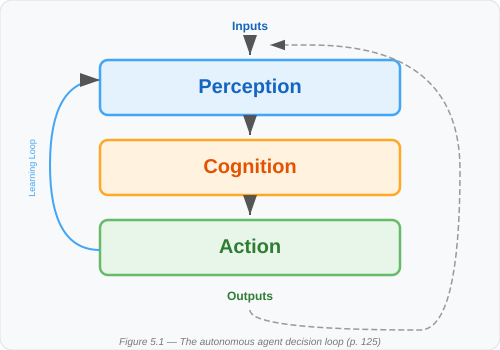

In [3]:
# ── Figure 5.1 — The Autonomous Agent Decision Loop (SVG) ──
# Ref: Section 5.1, p. 125

from IPython.display import SVG, display

fig_5_1 = """
<svg viewBox="0 0 500 350" xmlns="http://www.w3.org/2000/svg" font-family="Arial, sans-serif">
  <defs><marker id="a51" markerWidth="10" markerHeight="7" refX="10" refY="3.5" orient="auto"><polygon points="0 0,10 3.5,0 7" fill="#555"/></marker></defs>
  <rect width="500" height="350" rx="12" fill="#f8f9fa" stroke="#dee2e6"/>
  <!-- Inputs label -->
  <text x="250" y="30" text-anchor="middle" font-size="12" fill="#1565c0" font-weight="bold">Inputs</text>
  <line x1="250" y1="35" x2="250" y2="55" stroke="#1565c0" stroke-width="2" marker-end="url(#a51)"/>
  <!-- Perception -->
  <rect x="100" y="60" width="300" height="55" rx="8" fill="#e3f2fd" stroke="#42a5f5" stroke-width="2.5"/>
  <text x="250" y="93" text-anchor="middle" font-size="20" font-weight="bold" fill="#1565c0">Perception</text>
  <!-- Arrow P→C -->
  <line x1="250" y1="115" x2="250" y2="135" stroke="#555" stroke-width="2" marker-end="url(#a51)"/>
  <!-- Cognition -->
  <rect x="100" y="140" width="300" height="55" rx="8" fill="#fff3e0" stroke="#ffa726" stroke-width="2.5"/>
  <text x="250" y="173" text-anchor="middle" font-size="20" font-weight="bold" fill="#e65100">Cognition</text>
  <!-- Arrow C→A -->
  <line x1="250" y1="195" x2="250" y2="215" stroke="#555" stroke-width="2" marker-end="url(#a51)"/>
  <!-- Action -->
  <rect x="100" y="220" width="300" height="55" rx="8" fill="#e8f5e9" stroke="#66bb6a" stroke-width="2.5"/>
  <text x="250" y="253" text-anchor="middle" font-size="20" font-weight="bold" fill="#2e7d32">Action</text>
  <!-- Outputs -->
  <text x="250" y="300" text-anchor="middle" font-size="12" fill="#2e7d32" font-weight="bold">Outputs</text>
  <!-- Feedback loop -->
  <path d="M 250 310 Q 250 330 420 330 Q 460 330 460 170 Q 460 45 310 45 L 270 45" fill="none" stroke="#999" stroke-width="1.5" stroke-dasharray="6,3" marker-end="url(#a51)"/>
  <!-- Feedback arrow back from Action to Perception -->
  <path d="M 100 250 Q 50 250 50 165 Q 50 80 100 80" fill="none" stroke="#42a5f5" stroke-width="2" marker-end="url(#a51)"/>
  <text x="35" y="168" text-anchor="middle" font-size="9" fill="#42a5f5" transform="rotate(-90, 35, 168)">Learning Loop</text>
  <!-- Caption -->
  <text x="250" y="345" text-anchor="middle" font-size="10" fill="#777" font-style="italic">Figure 5.1 — The autonomous agent decision loop (p. 125)</text>
</svg>
"""
display(SVG(fig_5_1))


In [ ]:
# ── Perception Module ──────────────────────────────────────────
# Perception: From raw input to structured
# intelligence 
#
# The enhanced perception system goes beyond simple input processing;
# it provides the agent with situational awareness that enables
# autonomous decision-making. When a user reports an issue, the
# agent considers system load, time of day, user priority, and
# current alerts to make informed decisions.

log_section("Perception Module")


@fail_gracefully(
    fallback_value={"message": "", "error": "perception_failed"}
)
def analyze_sentiment(text: str) -> str:
    """Return sentiment label for the given text.

    Args:
        text: User message to analyze.

    Returns:
        Sentiment label: 'positive', 'neutral', or 'negative'.


    """
    # classify_text_sentiment stub
    negative_words = {"down", "slow", "broken", "issue", "problem",
                      "can't", "error", "intermittent", "frustrated"}
    positive_words = {"thanks", "great", "helped", "resolved", "good"}
    words = set(text.lower().split())
    if words & negative_words:
        return "negative"
    if words & positive_words:
        return "positive"
    return "neutral"


@fail_gracefully(
    fallback_value=[],
)
def check_system_alerts() -> list:
    """Return list of active system alert IDs.

    """
    # Simulated system alerts
    alerts = ["NET-2026-0042: Regional connectivity degradation"]
    log_info(f"System alerts retrieved: {len(alerts)} active")
    return alerts


@fail_gracefully(
    fallback_value="standard",
)
def get_user_tier(user_id: str) -> str:
    """Return account tier for the given user.

    Args:
        user_id: Customer identifier.

    Returns:
        Tier string: 'standard', 'premium', or 'enterprise'.

    """
    # Simulated CRM lookup
    tiers = {
        "premium_biz_123": "premium",
        "enterprise_500": "enterprise",
        "patient_42": "standard",
    }
    tier = tiers.get(user_id, "standard")
    log_info(f"User tier for '{user_id}': {tier}")
    return tier


@fail_gracefully(
    fallback_value=True
)
def check_human_agent_status() -> bool:
    """Check whether human agents are available for escalation.

    Returns:
        True if at least one human agent is online.
    """
    log_info("Human agent availability: True (simulated)")
    return True


@fail_gracefully(
    fallback_value={"message": "", "error": "perception_failed"}
)
def enhanced_perception(
    user_message: str,
    context: dict,
    system_state: dict,
) -> dict:
    """Build a rich perception dict from user message + environment.

    Combines the base perception (message, timestamp, sentiment)
    with system-wide context (load, alerts, user tier, agent
    availability) to enable autonomous decision-making.

    Args:
        user_message: Raw user input text.
        context: Session context dict with 'user_id', 'session' keys.
        system_state: Dict with 'active_sessions' and other runtime data.

    Returns:
        Structured perception dict with 10+ fields.

    """
    user_id = context.get("user_id", "unknown")

    # Base perception
    perception = {
        "message": user_message,
        "timestamp": datetime.now(),
        "user_id": user_id,
        "session_state": context.get("session", "new"),
        "sentiment": analyze_sentiment(user_message),
    }

    # Enhanced with environmental awareness
    perception.update({
        "current_load": system_state.get("active_sessions", 0),
        "time_of_day": datetime.now().hour,
        "user_tier": get_user_tier(user_id),
        "recent_issues": check_system_alerts(),
        "agent_availability": check_human_agent_status(),
    })

    log_success(
        f"Perception complete: intent signal='{perception['sentiment']}', "
        f"tier='{perception['user_tier']}', "
        f"alerts={len(perception['recent_issues'])}"
    )
    return perception


# ── Quick test ─────────────────────────────────────────────────
test_perception = enhanced_perception(
    user_message="My business internet has been intermittent for two days",
    context={"user_id": "premium_biz_123", "session": "new"},
    system_state={"active_sessions": 42},
)
log_info(f"Perception keys: {list(test_perception.keys())}")
log_info(f"Enhanced Perception : {(test_perception)}")


────────────────────────────────────────────────────────────
  Perception Module
────────────────────────────────────────────────────────────

[INFO  12:58:24] User tier for 'premium_biz_123': premium
[INFO  12:58:24] System alerts retrieved: 1 active
[INFO  12:58:24] Human agent availability: True (simulated)
[SUCCESS 12:58:24] Perception complete: intent signal='negative', tier='premium', alerts=1
[INFO  12:58:24] Perception keys: ['message', 'timestamp', 'user_id', 'session_state', 'sentiment', 'current_load', 'time_of_day', 'user_tier', 'recent_issues', 'agent_availability']
[INFO  12:58:24] Enhanced Perception : {'message': 'My business internet has been intermittent for two days', 'timestamp': datetime.datetime(2026, 9, 15, 12, 58, 24, 891553), 'user_id': 'premium_biz_123', 'session_state': 'new', 'sentiment': 'negative', 'current_load': 42, 'time_of_day': 12, 'user_tier': 'premium', 'recent_issues': ['NET-2026-0042: Regional connectivity degradation'], 'agent_availability': Tru

> **📝 Note — Strategy Scoring Framework**  
> The agent scores each candidate strategy across four weighted axes: **autonomy_level_score** (0–1), **urgency_score** (0–1), **complexity_score** (0–1), and **escalation_threshold** (0–1). The strategy with the highest composite score wins; ties favour guided resolution. The three strategies are: *full autonomous resolution*, *immediate escalation*, and *guided autonomous resolution* (baseline fallback at 0.5).

> **📝 Note — Task DAGs **  
> Action plans are built as dependency-aware task DAGs (directed acyclic graphs). Each node has an `id`, `action`, and `depends_on` list. Tasks with empty `depends_on` run immediately; downstream tasks wait until all listed IDs complete. The chapter provides three DAG templates: billing issues (8 tasks), service outages (6 tasks), and a generic fallback (4 tasks).


In [12]:
# ── Cognition Module: Strategic Reasoning ──────────────────────
# The reasoning component evaluates three candidate strategies
# across weighted axes (autonomy, urgency, complexity, escalation).
# The strategy with the highest composite score wins; ties favour
# guided resolution.

log_section("Cognition Module")

@fail_gracefully(
    fallback_value="general_inquiry"
)
def classify_intent(message: str) -> str:
    """Classify user message intent using LLM or keyword heuristic.

    Args:
        message: User message text.

    Returns:
        Intent label string.

    """
    response = llm_client.generate(message)
    log_info(f"Intent classified: '{response.intent}' "
             f"(confidence: {response.confidence})")
    return response.intent


@fail_gracefully(
    fallback_value=3,
)
def determine_priority(
    intent: str,
    sentiment: str,
    user_history: dict | None = None,
) -> int:
    """Determine issue priority on a 1-5 scale.

    Args:
        intent: Classified intent label.
        sentiment: Sentiment from perception ('positive'/'neutral'/'negative').
        user_history: Optional user history dict.

    Returns:
        Priority integer (1=lowest, 5=highest).

    """
    base = {"service_outage": 4, "billing_issue": 3, "complex_technical": 5}
    priority = base.get(intent, 2)
    if sentiment == "negative":
        priority = min(priority + 1, 5)
    log_info(f"Priority determined: {priority}/5 "
             f"(intent='{intent}', sentiment='{sentiment}')")
    return priority


@fail_gracefully(
    fallback_value="guided_autonomous_resolution",
)
def determine_autonomy_level(
    user_tier: str,
    current_load: int,
    agent_availability: bool,
) -> float:
    """Compute autonomy level score [0.0-1.0].

    Higher tier + higher load + lower agent availability
    = higher autonomy level.

    """
    tier_scores = {"enterprise": 0.9, "premium": 0.8, "standard": 0.5}
    tier_score = tier_scores.get(user_tier, 0.5)
    load_factor = min(current_load / 100, 1.0)
    availability_factor = 0.3 if not agent_availability else 0.0
    return round(min(tier_score + load_factor * 0.2 + availability_factor, 1.0), 2)


@fail_gracefully(
    fallback_value=0.5,
)
def calculate_escalation_threshold(
    time_of_day: int,
    intent: str,
    priority: int,
) -> float:
    """Calculate the escalation threshold [0.0-1.0].

    Lower threshold = easier to escalate.

    """
    base = 0.5
    if priority >= 4:
        base -= 0.15
    if time_of_day < 8 or time_of_day > 20:  # After hours
        base -= 0.1
    return round(max(base, 0.1), 2)


@fail_gracefully(
    fallback_value={
        "intent": "general_inquiry",
        "strategy": "guided_autonomous_resolution",
    },
)
def autonomous_reasoning(perception_data: dict) -> dict:
    """Autonomous cognition: classify, prioritize, select strategy.

    Implements the 3-strategy scoring system:
    - full_autonomous_resolution
    - immediate_escalation
    - guided_autonomous_resolution (baseline fallback at 0.5)

    The strategy with the highest composite score wins.

    Args:
        perception_data: Structured dict from enhanced_perception().

    Returns:
        Decision context dict with intent, priority, strategy,
        scores, and all supporting data.

    """
    # Basic intent and priority (Ref: p. 121)
    intent = classify_intent(perception_data["message"])
    priority = determine_priority(
        intent,
        perception_data.get("sentiment", "neutral"),
    )

    # Autonomy and escalation parameters (Ref: p. 121)
    autonomy_level = determine_autonomy_level(
        perception_data.get("user_tier", "standard"),
        perception_data.get("current_load", 0),
        perception_data.get("agent_availability", True),
    )
    escalation_threshold = calculate_escalation_threshold(
        perception_data.get("time_of_day", 12),
        intent,
        priority,
    )

    # Build decision context
    decision_context = {
        "intent": intent,
        "priority": priority,
        "context": perception_data,
        "autonomy_level_score": autonomy_level,
        "escalation_threshold": escalation_threshold,
        "urgency_score": priority / 5.0,
        "complexity_score": 0.85 if intent == "complex_technical" else 0.3,
        "agent_availability": perception_data.get("agent_availability", True),
    }

    # ── Strategy scoring ───────────────────────
    # Three weighted axes per strategy. Highest composite wins.
    strategy_scores = {
        "full_autonomous_resolution": (
            decision_context["autonomy_level_score"] * 0.5
            + (1 - decision_context["escalation_threshold"]) * 0.3
            + (1 - decision_context["complexity_score"]) * 0.2
        ),
        "immediate_escalation": (
            decision_context["urgency_score"] * 0.4
            + (0.4 if not decision_context["agent_availability"] else 0.0)
            + decision_context["escalation_threshold"] * 0.2
        ),
        "guided_autonomous_resolution": 0.5,  # baseline fallback
    }

    # Round scores for readability
    strategy_scores = {k: round(v, 3) for k, v in strategy_scores.items()}

    # Strategy with highest score wins; ties favour guided resolution
    decision_context["strategy"] = max(
        strategy_scores, key=strategy_scores.get
    )
    decision_context["strategy_scores"] = strategy_scores

    log_success(
        f"Strategy selected: '{decision_context['strategy']}' "
        f"| Scores: {strategy_scores}"
    )
    return decision_context


# ── Quick test ─────────────────────────────────────────────────
test_decision = autonomous_reasoning(test_perception)
log_info(f"Decision intent: {test_decision['intent']}"
         f"strategy: {test_decision['strategy']}"
         f"decision_context: {test_decision}")


────────────────────────────────────────────────────────────
  Cognition Module
────────────────────────────────────────────────────────────

[INFO  13:20:13] Intent classified: 'service_outage' (confidence: 0.9)
[INFO  13:20:13] Priority determined: 5/5 (intent='service_outage', sentiment='negative')
[SUCCESS 13:20:13] Strategy selected: 'full_autonomous_resolution' | Scores: {'full_autonomous_resolution': 0.775, 'immediate_escalation': 0.47, 'guided_autonomous_resolution': 0.5}
[INFO  13:20:13] Decision intent: service_outagestrategy: full_autonomous_resolutiondecision_context: {'intent': 'service_outage', 'priority': 5, 'context': {'message': 'My business internet has been intermittent for two days', 'timestamp': datetime.datetime(2026, 9, 15, 12, 58, 24, 891553), 'user_id': 'premium_biz_123', 'session_state': 'new', 'sentiment': 'negative', 'current_load': 42, 'time_of_day': 12, 'user_tier': 'premium', 'recent_issues': ['NET-2026-0042: Regional connectivity degradation'], 'agent_a

In [13]:
# ── Action Module: Task DAG & Execution ────────────────────────
# Action: Autonomous execution and adaptation
#
# The action module translates reasoning into real-world outcomes.
# Tasks are organized as a dependency-aware DAG. Each node has an
# id, action, and depends_on list. Tasks with empty depends_on
# run immediately; downstream tasks wait until dependencies complete.

log_section("Action Module")


@fail_gracefully(
    fallback_value=[]
)
def create_autonomous_plan(decision_context: dict) -> list[dict]:
    """Create a dependency-aware task DAG based on intent.

    Builds a list of task dicts, each with 'id', 'action', and
    'depends_on' keys. Supports billing_issue, service_outage,
    and default resolution workflows.

    Args:
        decision_context: Decision dict from autonomous_reasoning().

    Returns:
        List of task dicts forming a DAG.

    """
    intent = decision_context.get("intent", "general_inquiry")

    # billing_issue DAG
    if intent == "billing_issue":
        plan = [
            {"id": "T1", "action": "fetch_account_details", "depends_on": []},
            {"id": "T2", "action": "analyze_billing_history", "depends_on": ["T1"]},
            {"id": "T3", "action": "identify_discrepancies", "depends_on": ["T2"]},
            {"id": "T4", "action": "calculate_adjustments", "depends_on": ["T3"]},
            {"id": "T5", "action": "generate_explanation", "depends_on": ["T3"]},
            {"id": "T6", "action": "apply_account_credits", "depends_on": ["T4"]},
            {"id": "T7", "action": "send_confirmation_email", "depends_on": ["T5", "T6"]},
            {"id": "T8", "action": "schedule_follow_up", "depends_on": ["T7"]},
        ]

    #  service_outage DAG
    elif intent == "service_outage":
        plan = [
            {"id": "T1", "action": "check_service_status", "depends_on": []},
            {"id": "T2", "action": "identify_affected_areas", "depends_on": ["T1"]},
            {"id": "T3", "action": "estimate_resolution_time", "depends_on": ["T1"]},
            {"id": "T4", "action": "send_proactive_notifications", "depends_on": ["T2", "T3"]},
            {"id": "T5", "action": "monitor_restoration_progress", "depends_on": ["T1"]},
            {"id": "T6", "action": "update_customer_status", "depends_on": ["T4", "T5"]},
        ]

    # default resolution workflow
    else:
        plan = [
            {"id": "T1", "action": "analyze_issue", "depends_on": []},
            {"id": "T2", "action": "research_solutions", "depends_on": ["T1"]},
            {"id": "T3", "action": "implement_resolution", "depends_on": ["T2"]},
            {"id": "T4", "action": "verify_success", "depends_on": ["T3"]},
        ]

    log_info(f"Plan created for '{intent}': {len(plan)} tasks")
    for task in plan:
        deps = task["depends_on"] if task["depends_on"] else ["(none)"]
        log_info(f"  {task['id']}: {task['action']} → depends_on: {deps}")
    return plan


@fail_gracefully(
    fallback_value=[],
)
def execute_task(task: dict, completed: dict) -> dict:
    """Execute a single task from the DAG.

    Simulates task execution and returns a result dict.

    Args:
        task: Task dict with 'id', 'action', 'depends_on'.
        completed: Dict of already-completed task results.

    Returns:
        Result dict with 'task_id', 'action', 'status', 'timestamp'.

    """
    result = {
        "task_id": task["id"],
        "action": task["action"],
        "status": "completed",
        "timestamp": datetime.now().isoformat(),
    }
    log_success(f"Task {task['id']} ({task['action']}): completed")
    return result


@fail_gracefully(
    fallback_value=[],
)
def autonomous_action_execution(decision_context: dict) -> list[dict]:
    """Execute the autonomous action plan based on selected strategy.

    Dispatches to the appropriate execution path:
    - full_autonomous_resolution: build + execute full task DAG
    - immediate_escalation: prepare handoff package
    - guided_autonomous_resolution: execute with checkpoints

    Args:
        decision_context: Decision dict from autonomous_reasoning().

    Returns:
        List of task result dicts.

    """
    strategy = decision_context.get("strategy", "guided_autonomous_resolution")
    results = []

    if strategy == "full_autonomous_resolution":
        # Execute the full resolution workflow autonomously
        action_plan = create_autonomous_plan(decision_context)
        completed = {}

        # Topological execution: respect depends_on ordering
        remaining = list(action_plan)
        while remaining:
            ready = [
                t for t in remaining
                if all(d in completed for d in t["depends_on"])
            ]
            if not ready:
                log_error("Circular dependency detected in task DAG!")
                break
            for task in ready:
                result = execute_task(task, completed)
                completed[task["id"]] = result
                results.append(result)
                remaining.remove(task)

    elif strategy == "immediate_escalation":
        # Prepare comprehensive handoff to human agent
        log_warn("Escalation path: preparing handoff package")
        results.append({
            "task_id": "ESC-1",
            "action": "prepare_escalation_package",
            "status": "completed",
            "timestamp": datetime.now().isoformat(),
            "escalation_data": {
                "intent": decision_context.get("intent"),
                "priority": decision_context.get("priority"),
                "complexity": decision_context.get("complexity_score"),
            },
        })

    else:  # guided_autonomous_resolution
        # Execute with checkpoints for human oversight
        action_plan = create_autonomous_plan(decision_context)
        completed = {}
        remaining = list(action_plan)
        while remaining:
            ready = [
                t for t in remaining
                if all(d in completed for d in t["depends_on"])
            ]
            if not ready:
                break
            for task in ready:
                result = execute_task(task, completed)
                completed[task["id"]] = result
                results.append(result)
                remaining.remove(task)
        log_info("Guided resolution: all checkpoints passed")

    log_success(
        f"Action execution complete: {len(results)} tasks, "
        f"strategy='{strategy}'"
    )
    return results


# ── Quick test ─────────────────────────────────────────────────
test_results = autonomous_action_execution(test_decision)
log_info(f"Execution produced {len(test_results)} task results")


────────────────────────────────────────────────────────────
  Action Module
────────────────────────────────────────────────────────────

[INFO  13:23:56] Plan created for 'service_outage': 6 tasks
[INFO  13:23:56]   T1: check_service_status → depends_on: ['(none)']
[INFO  13:23:56]   T2: identify_affected_areas → depends_on: ['T1']
[INFO  13:23:56]   T3: estimate_resolution_time → depends_on: ['T1']
[INFO  13:23:56]   T4: send_proactive_notifications → depends_on: ['T2', 'T3']
[INFO  13:23:56]   T5: monitor_restoration_progress → depends_on: ['T1']
[INFO  13:23:56]   T6: update_customer_status → depends_on: ['T4', 'T5']
[SUCCESS 13:23:56] Task T1 (check_service_status): completed
[SUCCESS 13:23:56] Task T2 (identify_affected_areas): completed
[SUCCESS 13:23:56] Task T3 (estimate_resolution_time): completed
[SUCCESS 13:23:56] Task T5 (monitor_restoration_progress): completed
[SUCCESS 13:23:56] Task T4 (send_proactive_notifications): completed
[SUCCESS 13:23:56] Task T6 (update_custom

In [14]:
# ── Safety Checks & Escalation Logic ──────────────────────────
# Guardrails and safety mechanisms and Escalation criteria 
#
# Safety checks evaluate financial impact limits, data access
# permissions, and customer impact risk. Escalation uses a
# 5-factor weighted scoring system.

log_section("Safety & Escalation")

@fail_gracefully(
    fallback_value=(True, [])
)
def autonomous_safety_check(
    decision_context: dict,
    planned_actions: list[dict],
) -> tuple[bool, list[str]]:
    """Evaluate planned actions against safety guardrails.

    Checks three categories:
    1. Financial impact limits (credit thresholds by tier)
    2. Data access permissions
    3. Customer impact risk assessment

    Args:
        decision_context: Decision dict from autonomous_reasoning().
        planned_actions: List of task dicts from create_autonomous_plan().

    Returns:
        Tuple of (is_safe: bool, violations: list[str]).

    """
    safety_violations = []
    action_names = [a.get("action", "") for a in planned_actions]

    # 1. Financial impact limits
    if "apply_account_credits" in action_names:
        credit_limit = {"premium": 500, "enterprise": 2000, "standard": 100}
        tier = decision_context.get("context", {}).get("user_tier", "standard")
        max_credit = credit_limit.get(tier, 100)
        simulated_credit = 75  # Simulated credit amount
        if simulated_credit > max_credit:
            safety_violations.append("credit_limit_exceeded")
            log_error(f"Credit ${simulated_credit} exceeds {tier} limit ${max_credit}")
        else:
            log_success(f"Credit ${simulated_credit} within {tier} limit ${max_credit}")

    # 2. Data access permissions
    sensitive_actions = {"access_medical_records", "view_financial_data"}
    if sensitive_actions & set(action_names):
        safety_violations.append("insufficient_data_permissions")
        log_error("Sensitive data access attempted without explicit permission")
    else:
        log_success("Data access permissions: OK")

    # 3. Impact assessment (Ref: p. 128)
    impact_risk = decision_context.get("complexity_score", 0.3)
    threshold = decision_context.get("escalation_threshold", 0.5)
    if impact_risk > threshold:
        safety_violations.append("high_impact_risk")
        log_warn(f"Impact risk ({impact_risk}) exceeds threshold ({threshold})")
    else:
        log_success(f"Impact risk ({impact_risk}) within threshold ({threshold})")

    is_safe = len(safety_violations) == 0
    status = "PASSED" if is_safe else f"FAILED ({len(safety_violations)} violations)"
    log_info(f"Safety check: {status}")
    return is_safe, safety_violations


@fail_gracefully(
    fallback_value=None,
    chapter_ref="Section 5.1, p. 131",
)
def intelligent_escalation_decision(
    decision_context: dict,
    safety_results: tuple[bool, list[str]],
) -> dict | None:
    """Determine whether to escalate based on 5 weighted factors.

    Factors: safety violations, confidence threshold, complexity
    threshold, user preference, and business impact.

    Args:
        decision_context: Decision dict from autonomous_reasoning().
        safety_results: Tuple from autonomous_safety_check().

    Returns:
        Escalation package dict if escalation needed, else None.

    """
    escalation_factors = {
        "safety_violations": not safety_results[0],
        "confidence_threshold": decision_context.get(
            "urgency_score", 0
        ) < 0.6,
        "complexity_threshold": decision_context.get(
            "complexity_score", 0
        ) > 0.7,
        "user_preference": False,  # Simulated: user has no preference
        "business_impact": decision_context.get("urgency_score", 0) > 0.8,
    }

    # Weighted escalation score
    weights = {
        "safety_violations": 0.30,
        "confidence_threshold": 0.20,
        "complexity_threshold": 0.25,
        "user_preference": 0.10,
        "business_impact": 0.15,
    }
    escalation_score = sum(
        weights[k] * (1.0 if v else 0.0)
        for k, v in escalation_factors.items()
    )
    escalation_score = round(escalation_score, 3)

    log_info(f"Escalation factors: {escalation_factors}")
    log_info(f"Escalation score: {escalation_score} "
             f"(threshold: {decision_context.get('escalation_threshold', 0.5)})")

    if escalation_score > decision_context.get("escalation_threshold", 0.5):
        log_warn("ESCALATION TRIGGERED — preparing handoff package")
        return {
            "escalation_score": escalation_score,
            "factors": escalation_factors,
            "decision_context_summary": {
                "intent": decision_context.get("intent"),
                "priority": decision_context.get("priority"),
                "strategy": decision_context.get("strategy"),
            },
        }

    log_success("No escalation needed — autonomous resolution continues")
    return None


# ── Quick test ─────────────────────────────────────────────────
test_plan = create_autonomous_plan(test_decision)
safety_ok, violations = autonomous_safety_check(test_decision, test_plan)
escalation = intelligent_escalation_decision(test_decision, (safety_ok, violations))
log_info(f"Safety: {safety_ok}, Escalation: {'triggered' if escalation else 'not needed'}")


────────────────────────────────────────────────────────────
  Safety & Escalation
────────────────────────────────────────────────────────────

[INFO  13:27:40] Plan created for 'service_outage': 6 tasks
[INFO  13:27:40]   T1: check_service_status → depends_on: ['(none)']
[INFO  13:27:40]   T2: identify_affected_areas → depends_on: ['T1']
[INFO  13:27:40]   T3: estimate_resolution_time → depends_on: ['T1']
[INFO  13:27:40]   T4: send_proactive_notifications → depends_on: ['T2', 'T3']
[INFO  13:27:40]   T5: monitor_restoration_progress → depends_on: ['T1']
[INFO  13:27:40]   T6: update_customer_status → depends_on: ['T4', 'T5']
[SUCCESS 13:27:40] Data access permissions: OK
[SUCCESS 13:27:40] Impact risk (0.3) within threshold (0.35)
[INFO  13:27:40] Safety check: PASSED
[INFO  13:27:40] Escalation factors: {'safety_violations': False, 'confidence_threshold': False, 'complexity_threshold': False, 'user_preference': False, 'business_impact': True}
[INFO  13:27:40] Escalation score: 0.1

In [15]:
# ── AutonomousCustomerServiceAgent ─────────────────────────────
# The continuous cognitive loop
#
# This class integrates all components into a single cognitive loop:
# perception → reasoning → safety check → action → learning.
# It maintains session_memory, decision_history, and
# performance_metrics across interactions.

log_section("AutonomousCustomerServiceAgent")


class AutonomousCustomerServiceAgent:
    """Complete autonomous agent with the cognitive loop.

    Integrates perception, cognition, action, and learning into a
    continuous cycle. Maintains session memory and decision history
    for adaptation across interactions.

    """

    def __init__(self) -> None:
        self.session_memory: dict = {}
        self.decision_history: list[dict] = []
        self.performance_metrics: dict = {"total_runs": 0, "successes": 0}

    def get_current_system_state(self) -> dict:
        """Return simulated system state for perception.

        """
        return {
            "active_sessions": 42,
            "system_load_pct": 65,
            "known_outages": ["NET-2026-0042"],
        }

    @fail_gracefully(
        fallback_value={"status": "cognitive_loop_failed"},
    )
    def cognitive_loop(
        self, user_message: str, context: dict
    ) -> list[dict]:
        """The complete autonomous decision-making cycle.

        Executes all four stages in sequence:
        1. Enhanced Perception
        2. Autonomous Reasoning
        3. Safety Check + Strategic Action Execution
        4. Learning and Adaptation

        Args:
            user_message: Raw user input.
            context: Session context dict.

        Returns:
            List of action result dicts.

        """
        log_section("Cognitive Loop START")

        # 1. Enhanced Perception
        system_state = self.get_current_system_state()
        perception_data = enhanced_perception(
            user_message, context, system_state
        )

        # 2. Autonomous Reasoning
        decision_context = autonomous_reasoning(perception_data)

        # 3. Safety Check + Action Execution
        planned_actions = create_autonomous_plan(decision_context)
        safety_ok, violations = autonomous_safety_check(
            decision_context, planned_actions
        )
        escalation = intelligent_escalation_decision(
            decision_context, (safety_ok, violations)
        )

        if escalation:
            decision_context["strategy"] = "immediate_escalation"

        results = autonomous_action_execution(decision_context)

        # 4. Learning and Adaptation
        self.learn_from_interaction(
            perception_data, decision_context, results
        )
        self.update_session_memory(
            context.get("user_id"), decision_context, results
        )

        log_section("Cognitive Loop END", chapter_ref="Section 5.1")
        return results

    def learn_from_interaction(
        self,
        perception_data: dict,
        decision_context: dict,
        results: list[dict],
    ) -> None:
        """Enhanced learning from interaction outcomes.

        Calculates success score, flags low-performing strategies,
        and stores the decision pattern for future reference.

        """
        # Calculate success
        completed = sum(1 for r in results if r.get("status") == "completed")
        total = max(len(results), 1)
        success_score = round(completed / total, 2)

        self.performance_metrics["total_runs"] += 1
        if success_score >= 0.7:
            self.performance_metrics["successes"] += 1
            log_success(f"Learning: success_score={success_score} (above threshold)")
        else:
            log_warn(
                f"Learning: success_score={success_score} — "
                f"flagging strategy '{decision_context.get('strategy')}' "
                f"for improvement"
            )

        # Store decision pattern
        self.decision_history.append({
            "perception_summary": {
                "intent": decision_context.get("intent"),
                "sentiment": perception_data.get("sentiment"),
            },
            "decision": {
                "strategy": decision_context.get("strategy"),
                "scores": decision_context.get("strategy_scores"),
            },
            "outcome": success_score,
            "timestamp": datetime.now(),
        })
        log_info(f"Decision history: {len(self.decision_history)} entries")

    def update_session_memory(
        self,
        user_id: str | None,
        decision_context: dict,
        results: list[dict],
    ) -> None:
        """Update session memory for cross-interaction continuity.
        """
        if user_id:
            self.session_memory[user_id] = {
                "last_intent": decision_context.get("intent"),
                "last_strategy": decision_context.get("strategy"),
                "tasks_completed": len(results),
                "timestamp": datetime.now().isoformat(),
            }
            log_info(f"Session memory updated for '{user_id}'")


log_success("AutonomousCustomerServiceAgent class defined")


────────────────────────────────────────────────────────────
  AutonomousCustomerServiceAgent
────────────────────────────────────────────────────────────

[SUCCESS 13:31:59] AutonomousCustomerServiceAgent class defined


In [16]:
# ── Case Study: Premium Business Customer Outage ───────────────
# Scenario: A premium customer reports:
# "My business internet has been intermittent for two days,
#  and I have a critical presentation tomorrow."
#
# The agent must: perceive the urgency + business context,
# reason about strategy, validate safety, execute autonomously,
# and learn from the outcome.

log_section(
    "CASE STUDY: Business-Critical Outage",
)

agent = AutonomousCustomerServiceAgent()

results = agent.cognitive_loop(
    user_message=(
        "My business internet has been intermittent for two days, "
        "and I have a critical presentation tomorrow."
    ),
    context={"user_id": "premium_biz_123", "session": "new"},
)

# ── Summary ────────────────────────────────────────────────────
log_section("Case Study Summary")
log_info(f"Total tasks executed: {len(results)}")
log_info(f"Agent performance: {agent.performance_metrics}")
log_info(f"Session memory keys: {list(agent.session_memory.keys())}")
log_info(f"Decision history entries: {len(agent.decision_history)}")

if all(r.get("status") == "completed" for r in results):
    log_success("All tasks completed successfully — autonomous resolution achieved")
else:
    log_warn("Some tasks did not complete — review logs above")


────────────────────────────────────────────────────────────
  CASE STUDY: Business-Critical Outage
────────────────────────────────────────────────────────────


────────────────────────────────────────────────────────────
  Cognitive Loop START
────────────────────────────────────────────────────────────

[INFO  13:33:08] User tier for 'premium_biz_123': premium
[INFO  13:33:08] System alerts retrieved: 1 active
[INFO  13:33:08] Human agent availability: True (simulated)
[SUCCESS 13:33:08] Perception complete: intent signal='negative', tier='premium', alerts=1
[INFO  13:33:13] Intent classified: 'service_outage' (confidence: 0.9)
[INFO  13:33:13] Priority determined: 5/5 (intent='service_outage', sentiment='negative')
[SUCCESS 13:33:13] Strategy selected: 'full_autonomous_resolution' | Scores: {'full_autonomous_resolution': 0.775, 'immediate_escalation': 0.47, 'guided_autonomous_resolution': 0.5}
[INFO  13:33:13] Plan created for 'service_outage': 6 tasks
[INFO  13:33:13]   T1: chec

### Analysis: Autonomous Decision-Making Agent

The case study above demonstrates the complete cognitive loop in action:

- **Perception**  — Enhanced context including system alerts, user tier, and agent availability.
- **Cognition**  — LLM-powered reasoning with strategy selection and escalation assessment.
- **Action** — Task DAG execution with dependency ordering and safety checks.
- **Learning** — Success scoring feeds back to refine future autonomy thresholds.

> **📝 Note — Five-Factor Escalation Scoring **  
> The agent uses five escalation factors: **safety_violations**, **confidence_threshold** (< 0.8), **complexity_threshold** (> 0.7), **user_preference**, and **business_impact** (> 0.6). A weighted escalation score is compared against the decision context's escalation threshold. This ensures that the agent can gracefully defer to a human operator for ambiguous situations, ethical dilemmas, or tasks beyond its capabilities.

> **📝 Note — Production Impact **  
> By combining structured prompts and conditional logic, such a bot can operate autonomously for up to **80% of user queries**, freeing human agents to focus on more nuanced and complex problems.
